# Pipeline
- ax is a param
- Takes in data loc
- Processes and splits the df (splits are a param)
- Clean the df
- Perform LSP
- Get priors
- Do the model comparison
- Plot the best model on ax and annotate it
- This will enable a moving window analysis.


In [7]:
# Importing and data hopo hopo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.time import Time
from astropy.timeseries import LombScargle

from scipy.signal import find_peaks
from scipy.optimize import curve_fit, minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.LSP_peaks import fit_peaks, set_period_axes
from helpers.df_ops import prepare_df, split_df
from helpers.priors import find_classify_signals, get_priors

In [8]:
# All the helper functions live here
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def clean_df(train_df, tol = 3, plot = True, verbose = True):
    '''
    This uses a median absolute deviance filter to remove any crazy outliers in the training data.

    Returns a df with the outliers removed.
    If plot, plots the removed values.
    If verbose, states number of removed values.
    '''
    med = train_df['sind'].median()
    mad = (train_df['sind'] - med).abs().median()
    cleaned_train_df = train_df[(train_df['sind'] - med).abs() < tol * mad]

    if verbose:
        l1 = len(train_df)
        l2 = len(cleaned_train_df)
        print(f"Removed {l1 - l2} datapoints that were deemed ourliers by tolerance in sind of {tol} times MAD.")
    
    if plot:
        fig, ax =plt.subplots(figsize=(20,5))
        ax.scatter(train_df['day'], train_df['sind'], 
           s=10, label='Removed points', alpha=0.5, color='red')
        ax.scatter(cleaned_train_df['day'], cleaned_train_df['sind'], 
                s=10, label='Remaining points', alpha=0.8, color='blue')
        ax.axhline((tol * mad)+med, label = "Threshold", color = 'orange', linestyle = "--")
        ax.legend()
        ax.set_xlabel("Days")
        ax.set_ylabel("SInd")
        plt.tight_layout()
        plt.show()
        

    return cleaned_train_df

In [ ]:
def train_gpr(
        datapath,
        add_prefix: bool = False, # whether or not to add the 240000 to the JD
        train_split: float = 0.8, valid_split: float = 0.19,
        star_type: str = None, star_name: str = None,
        error_percent: float = 2.5, # the percentage error of the input
        sigma_upper_mult: float = 5.0, rho_bound_mults = [0.9, 1.1], q_bounds_in = [5, 100],
        verbose = True, plot = True, # general outputs
        loop_verbose: bool = False, loop_plot: bool = False, loop_savefigs: bool = True, # output within the loop
        results_verbose: bool = True, results_plot: bool = True, ax = None, # output the results
        SEED = 1701
        ):
        # Read the data into a "raw" df
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix)

        # Split the data
        dirty_train_df, valid_df, test_df = split_df(data_df,
                                                     train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df = clean_df(dirty_train_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)
        priors = get_priors(classified_signal_data,
                                        star_type=star_type,
                                        verbose=verbose)

        #-----Do the model training and comparison---------
        train_yerr = train_df['sind'] * error_percent / 100

        train_mean = train_df['sind'].mean()
        train_std  = train_df['sind'].std()

        # Define the prior combos to try
        prior_combos = {
        "1s":   (1, [priors['short']]),
        "1m":   (1, [priors['mid']]),
        "1l":   (1, [priors['long']]),

        "2sm":  (2, [priors['short'], priors['mid']]),
        "2ml":  (2, [priors['mid'],   priors['long']]),
        "2ls":  (2, [priors['long'],  priors['short']]),

        "3sml": (3, [priors['short'], priors['mid'], priors['long']]),
        }

        # Set up the loop
        best_combo  = None
        best_NLPD   = np.inf
        best_gp     = None
        best_params = None

        # Run the loop
        for combo_name, (k, prior_combo) in prior_combos.items():
                np.random.seed(SEED)

                sigma_0s = [train_std / k for _ in range(k)]
                rho_0s   = prior_combo
                q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

                initial_guess = np.concatenate([
                        np.log(sigma_0s),
                        np.log(rho_0s),
                        np.log(q_0s)
                ])

                sigma_upper  = train_std * sigma_upper_mult
                sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
                rho_bounds   = [(np.log(rho * rho_bound_mults[0]), np.log(rho * rho_bound_mults[1])) for rho in rho_0s]
                q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

                bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

                # Create the initial kernel for this iteration
                kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                for k_idx in range(1, k):
                        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

                # Define and compute the GP
                gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                gp.compute(train_df['day'], yerr=train_yerr)

                # Train the GP
                gp_results = minimize(
                        NLL, initial_guess,
                        args=(gp, k, train_df['sind'].to_numpy()),
                        method='L-BFGS-B',
                        bounds=bounds
                        )

                gp   = set_params(gp_results.x, k, gp)
                gp.recompute()
                best = np.exp(gp_results.x)

                if loop_verbose:
                        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                        best_sigmas = best[0:k]
                        best_rhos   = best[k:2*k]
                        best_qs     = best[2*k:]
                        for k_idx in range(k):
                                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                               f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                        print(gp_results.success, gp_results.message)
                        print(f"For k = {k}")
                        print(table)

                # Predict on validation set
                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                std = np.sqrt(cov)

                # Model comparison via NLPD
                y_valid    = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var  = cov + valid_yerr**2
                nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
                mean_nlpd = nlpd_per_point.mean()

                if mean_nlpd < best_NLPD:
                        best_combo  = combo_name
                        best_NLPD   = mean_nlpd
                        best_gp     = gp
                        best_params = best

                if loop_plot:
                        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                        
                        loop_ax.set_title(star_name + " " + combo_name)

                        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                        loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                             color='green', alpha=0.2, label='Uncertainties')
                        
                        loop_ax.legend()

                        loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                                transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                        
                        if loop_savefigs:
                                loop_fig.savefig(f"./figs/gpr_{star_name}_{combo_name}.png", dpi=100, bbox_inches='tight')
                                plt.close(loop_fig)

                        else:
                                plt.show()

                if loop_verbose:
                        print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

        #-------Now we have the best model------

        # Predict the best model once
        mu, cov = best_gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)
        results = pd.DataFrame({
                'forecast': mu,
                'lower':    mu - std,
                'upper':    mu + std,
        }, index=valid_df.index)

        if results_verbose: # Print best model params
                print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
                (k, prior_combo) = prior_combos[best_combo]
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best_params[0:k]
                best_rhos   = best_params[k:2*k]
                best_qs     = best_params[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                       f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(table)

        if results_plot: # Plot best model predictions
                if ax is None: # Enables passthrough
                        fig, ax = plt.subplots(figsize=(20, 5))
                ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                ax.set_title(f"Best model for {star_name} is {best_combo}")
                ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
                ax.fill_between(valid_df['year'], results['lower'], results['upper'],
                                color='green', alpha=0.2, label='Uncertainties')
                ax.legend()
                ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        return best_gp

## Test this for one

Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


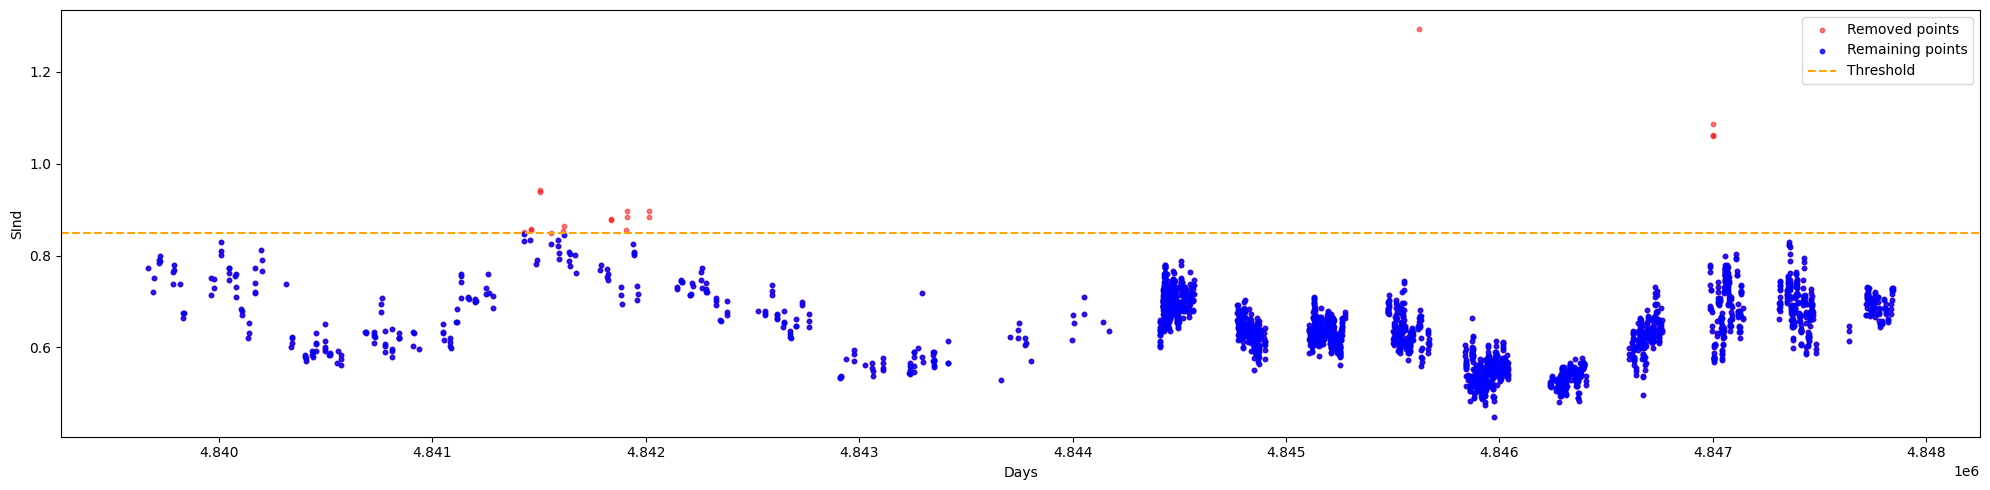

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

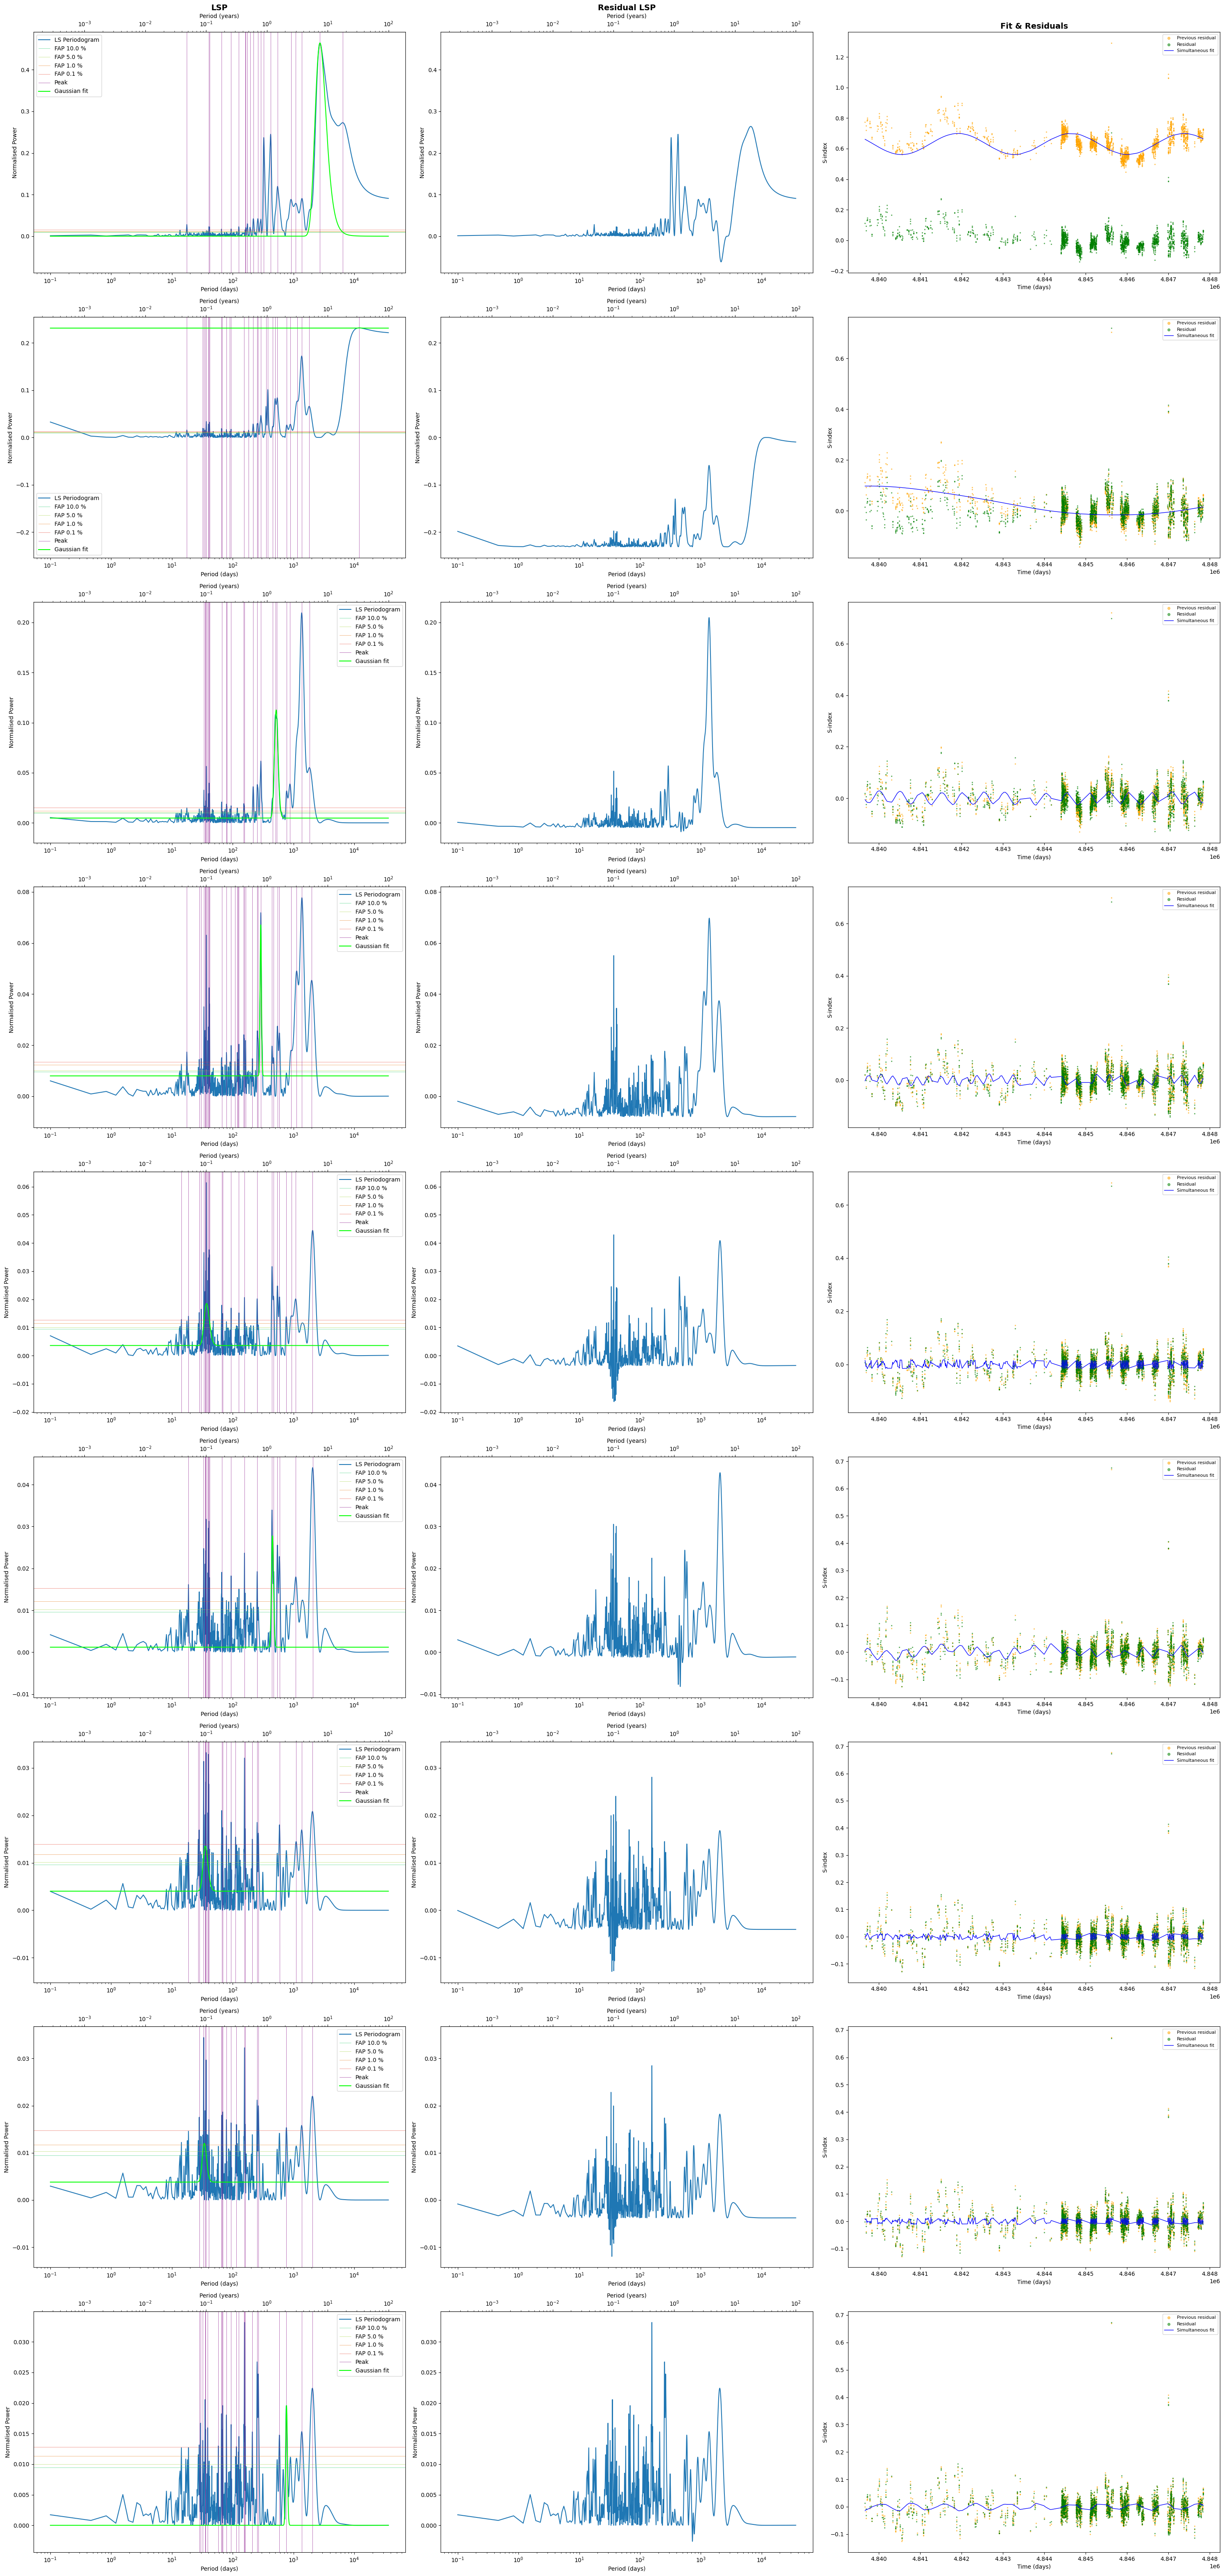

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 115896884.85 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


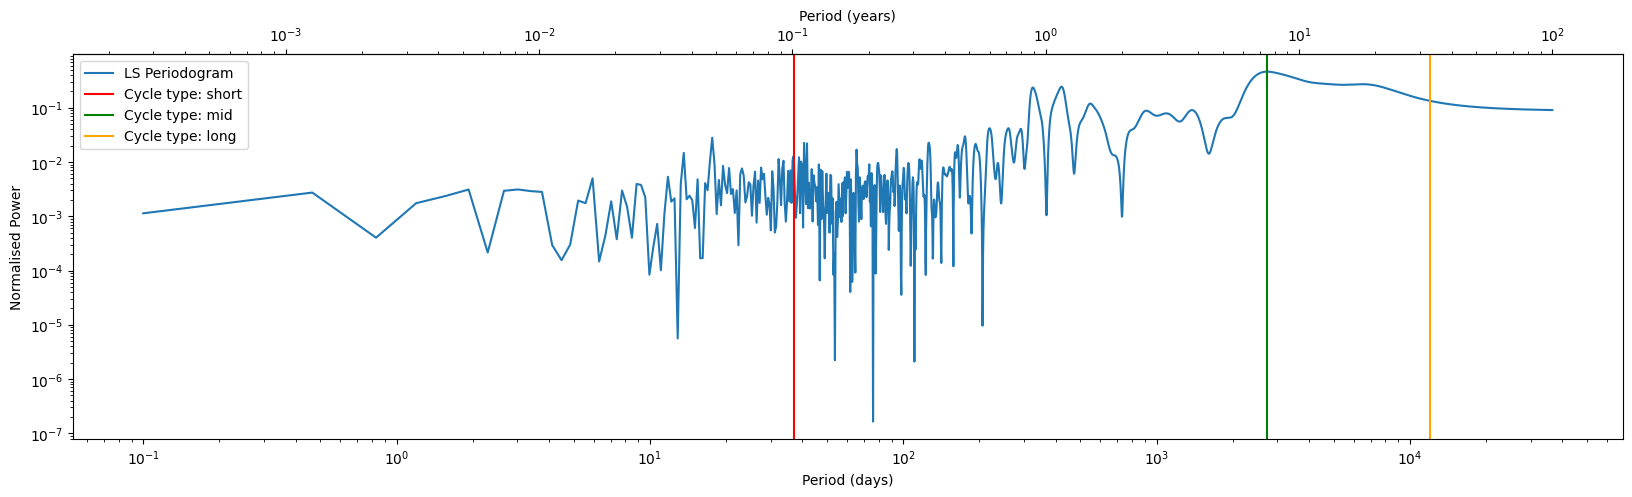

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+--------+
| Cycle Type | Prior Days | Prior Years | Source |
+------------+------------+-------------+--------+
|   Short    |   36.97    |     0.10    | found  |
|    Mid     |  2730.68   |     7.48    | found  |
|    Long    |  12043.36  |    33.00    | found  |
+------------+------------+-------------+--------+
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 1
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.1263 | 5.00 |   34.70    |     0.10    |
+--------+------+------------+-------------+


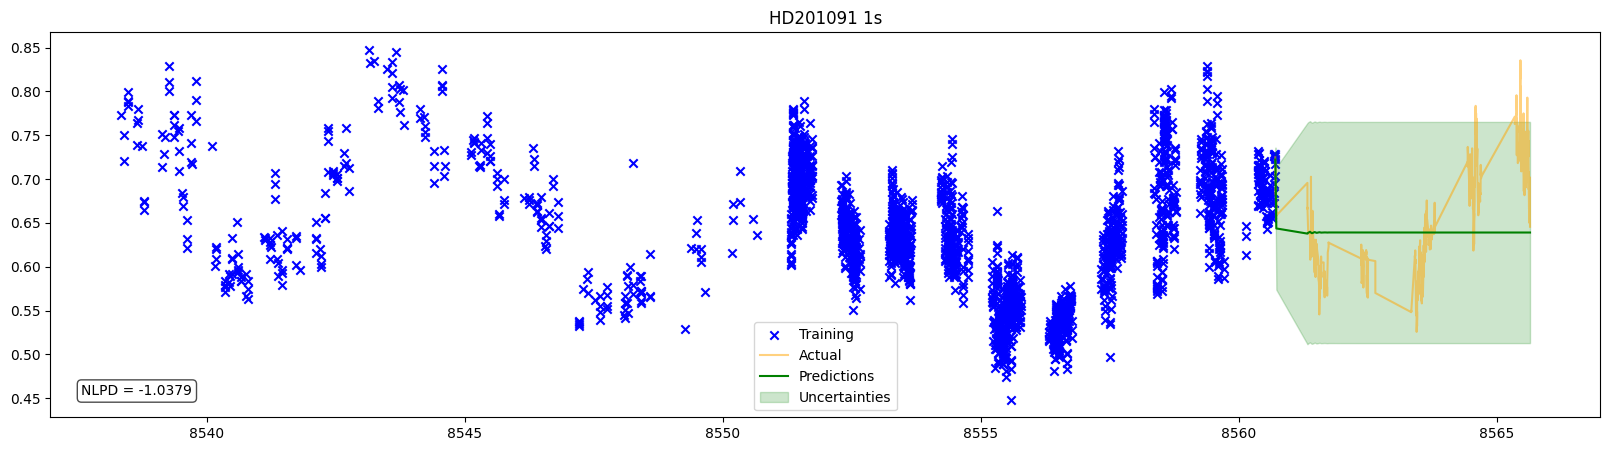

Mean NLPD on validation set (1s): -1.0379
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 1
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+


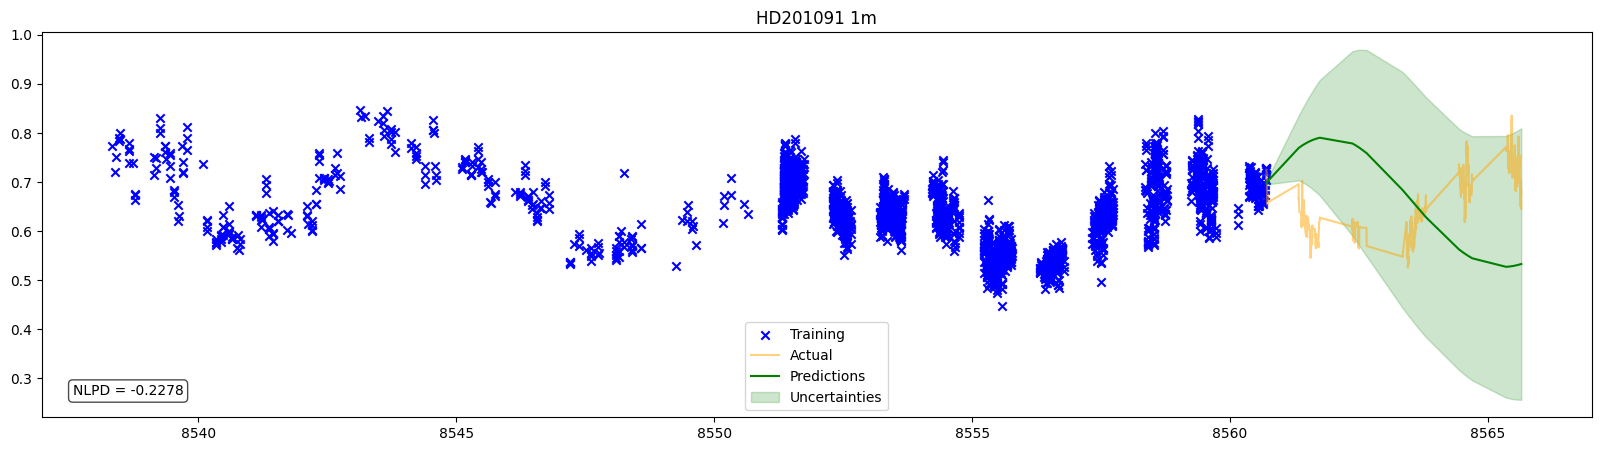

Mean NLPD on validation set (1m): -0.2278
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 1
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


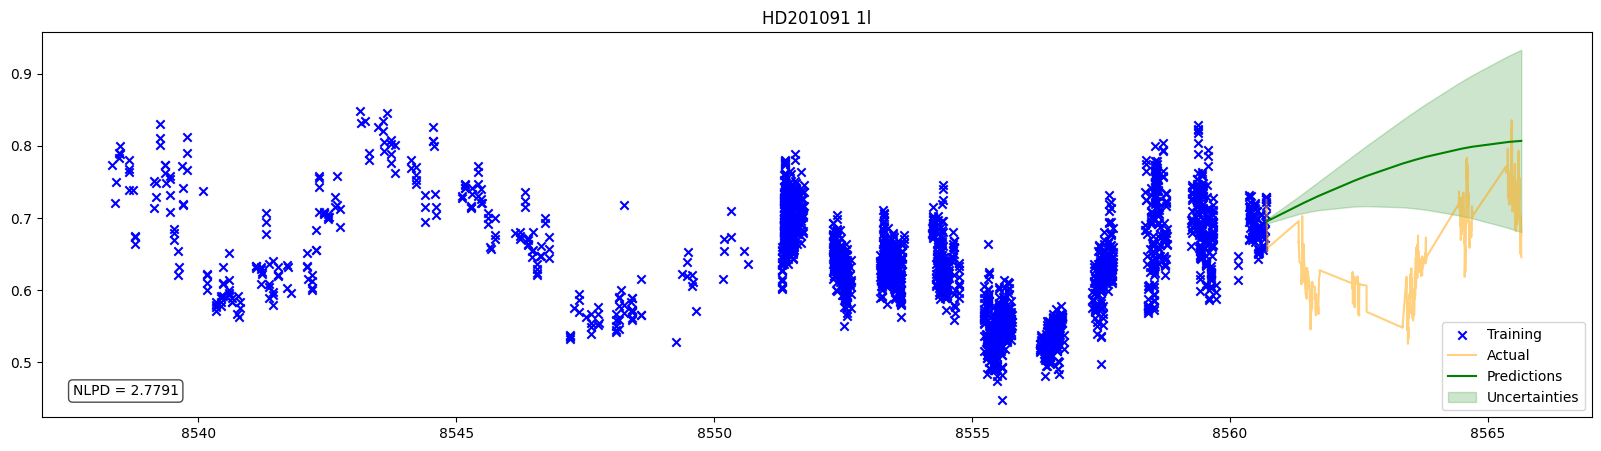

Mean NLPD on validation set (1l): 2.7791
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0600 | 5.00 |   33.27    |     0.09    |
| 0.1083 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+


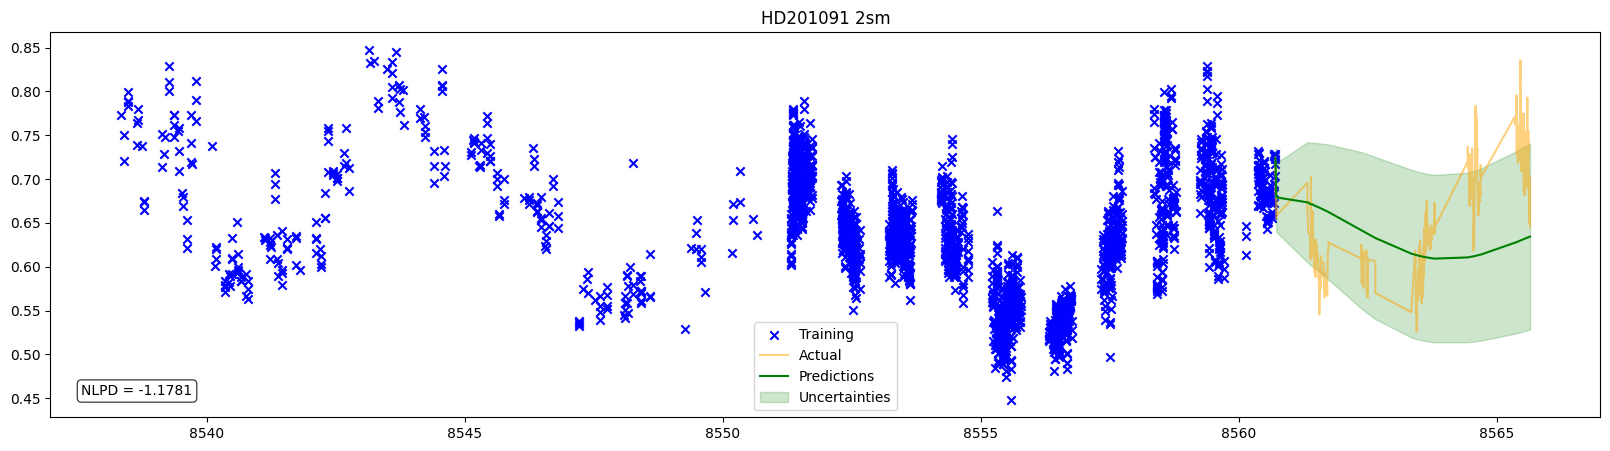

Mean NLPD on validation set (2sm): -1.1781
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
| 0.3572 | 5.00 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


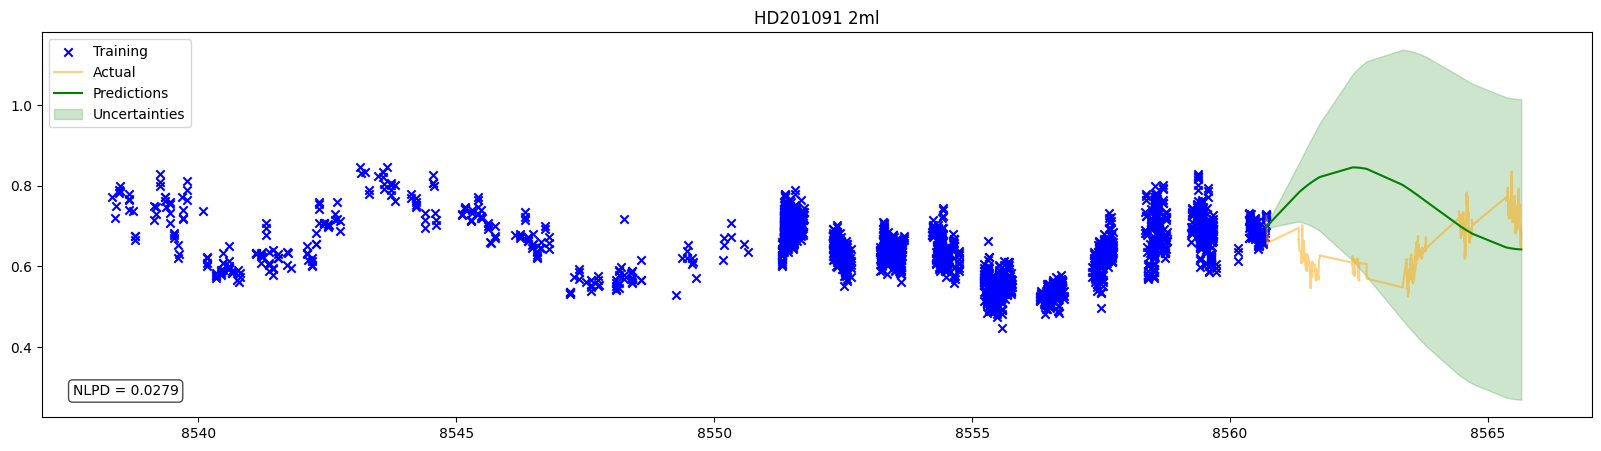

Mean NLPD on validation set (2ml): 0.0279
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  10839.03  |    29.70    |
| 0.0683 | 5.00 |   33.27    |     0.09    |
+--------+------+------------+-------------+


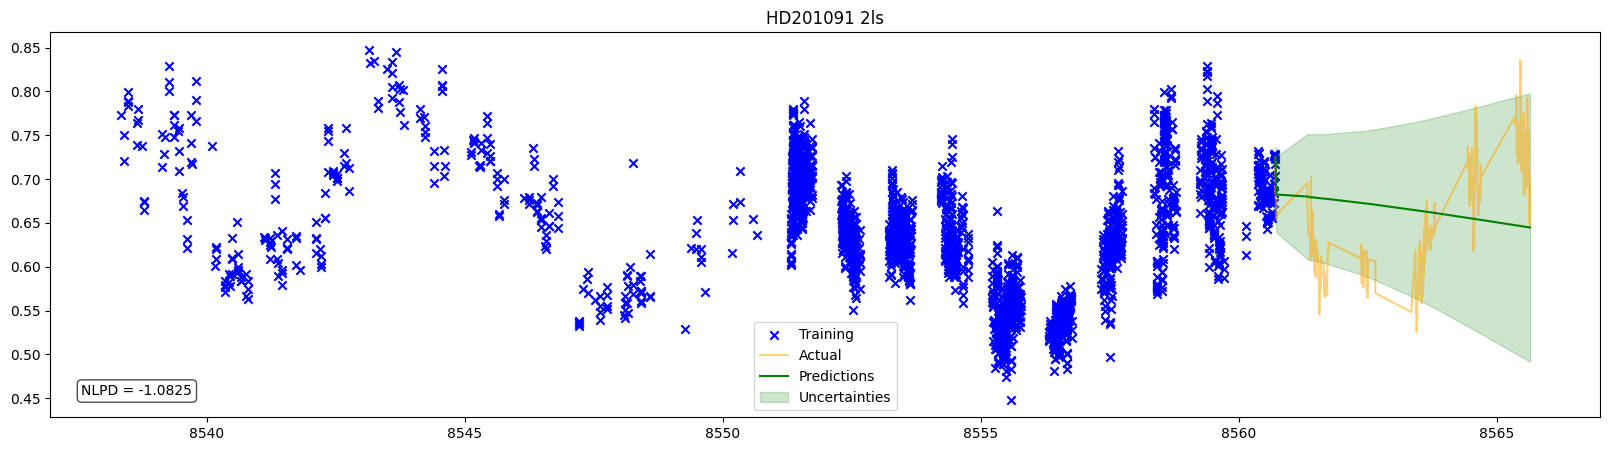

Mean NLPD on validation set (2ls): -1.0825
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 3
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0604 | 5.00 |   33.27    |     0.09    |
| 0.0951 | 5.00 |  2457.62   |     6.73    |
| 0.0255 | 5.05 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


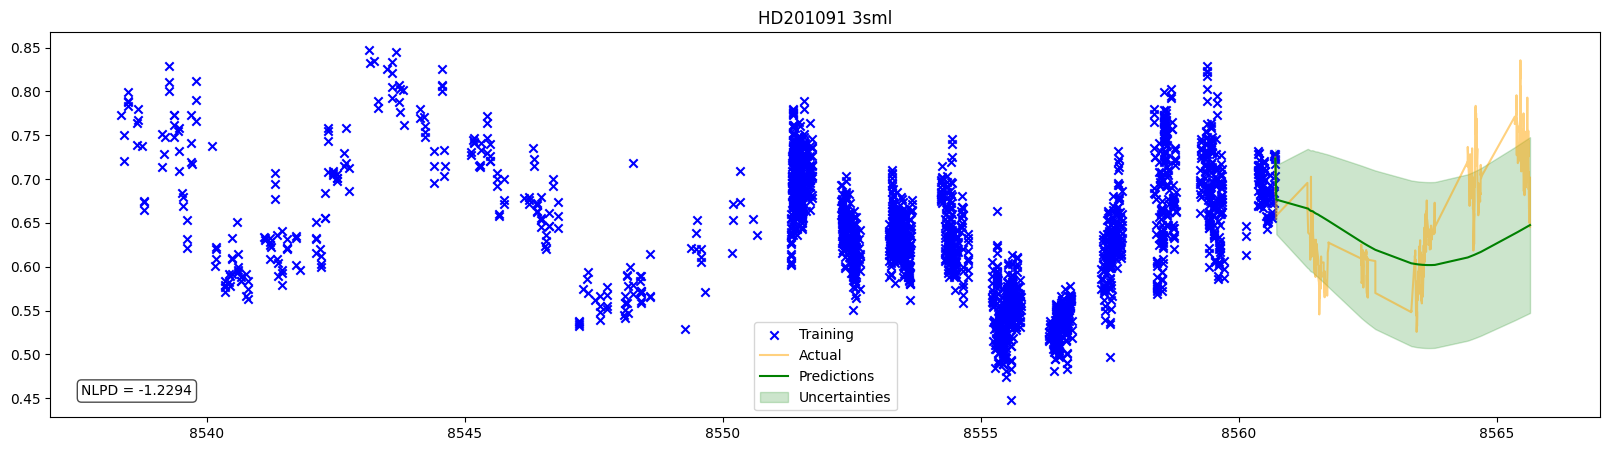

Mean NLPD on validation set (3sml): -1.2294
The best params were found for 3sml with NLPD of -1.229427716116637.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0604 | 5.00 |   33.27    |     0.09    |
| 0.0951 | 5.00 |  2457.62   |     6.73    |
| 0.0255 | 5.05 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


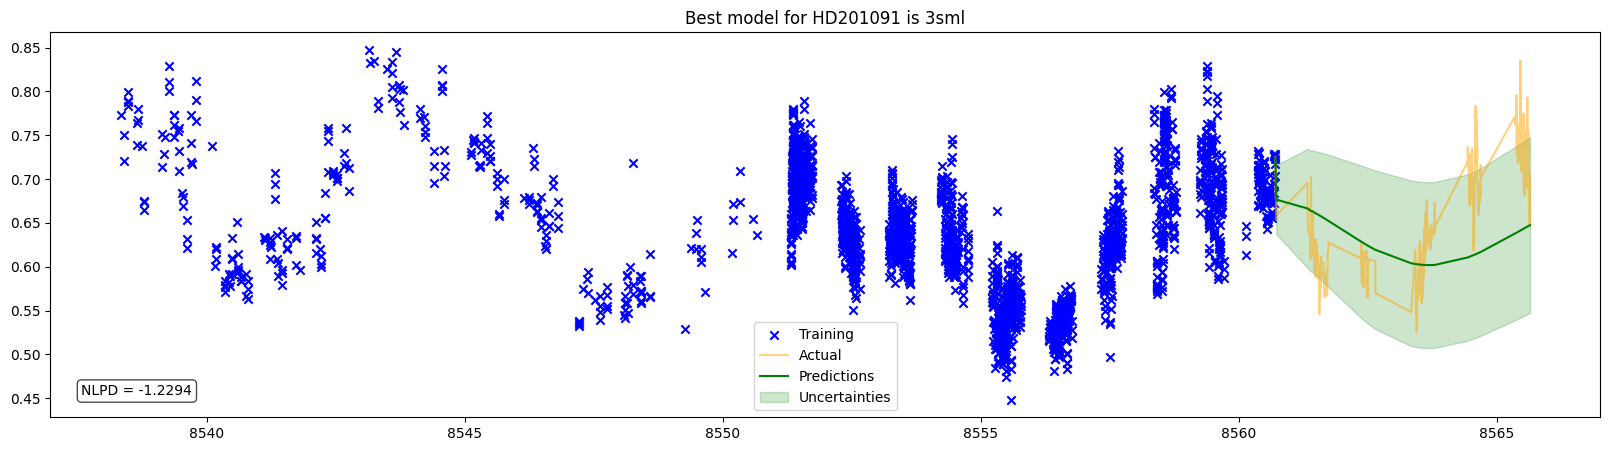

In [ ]:
best_gp = train_gpr(
    datapath    =  r"../../Data/benchmark/HD201091_Mt_wilson_data.txt",
    star_name   = 'HD201091',
    star_type   = 'G',
    add_prefix  = False,
    verbose          = True,
    plot             = True,
    loop_verbose     = True,
    loop_plot        = True,
    loop_savefigs    = False,   # show inline rather than saving
    results_verbose  = True,
    results_plot     = True,
)